In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [104]:
base_casas = pd.read_csv("D:/cursos/curso-machine-learning/bases_dados/house_prices.csv")
base_casas

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [80]:
base_casas.drop('date', axis=1, inplace=True)

In [81]:
base_casas.isnull().sum()

id               0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [82]:
base_casas.corr()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


<Axes: >

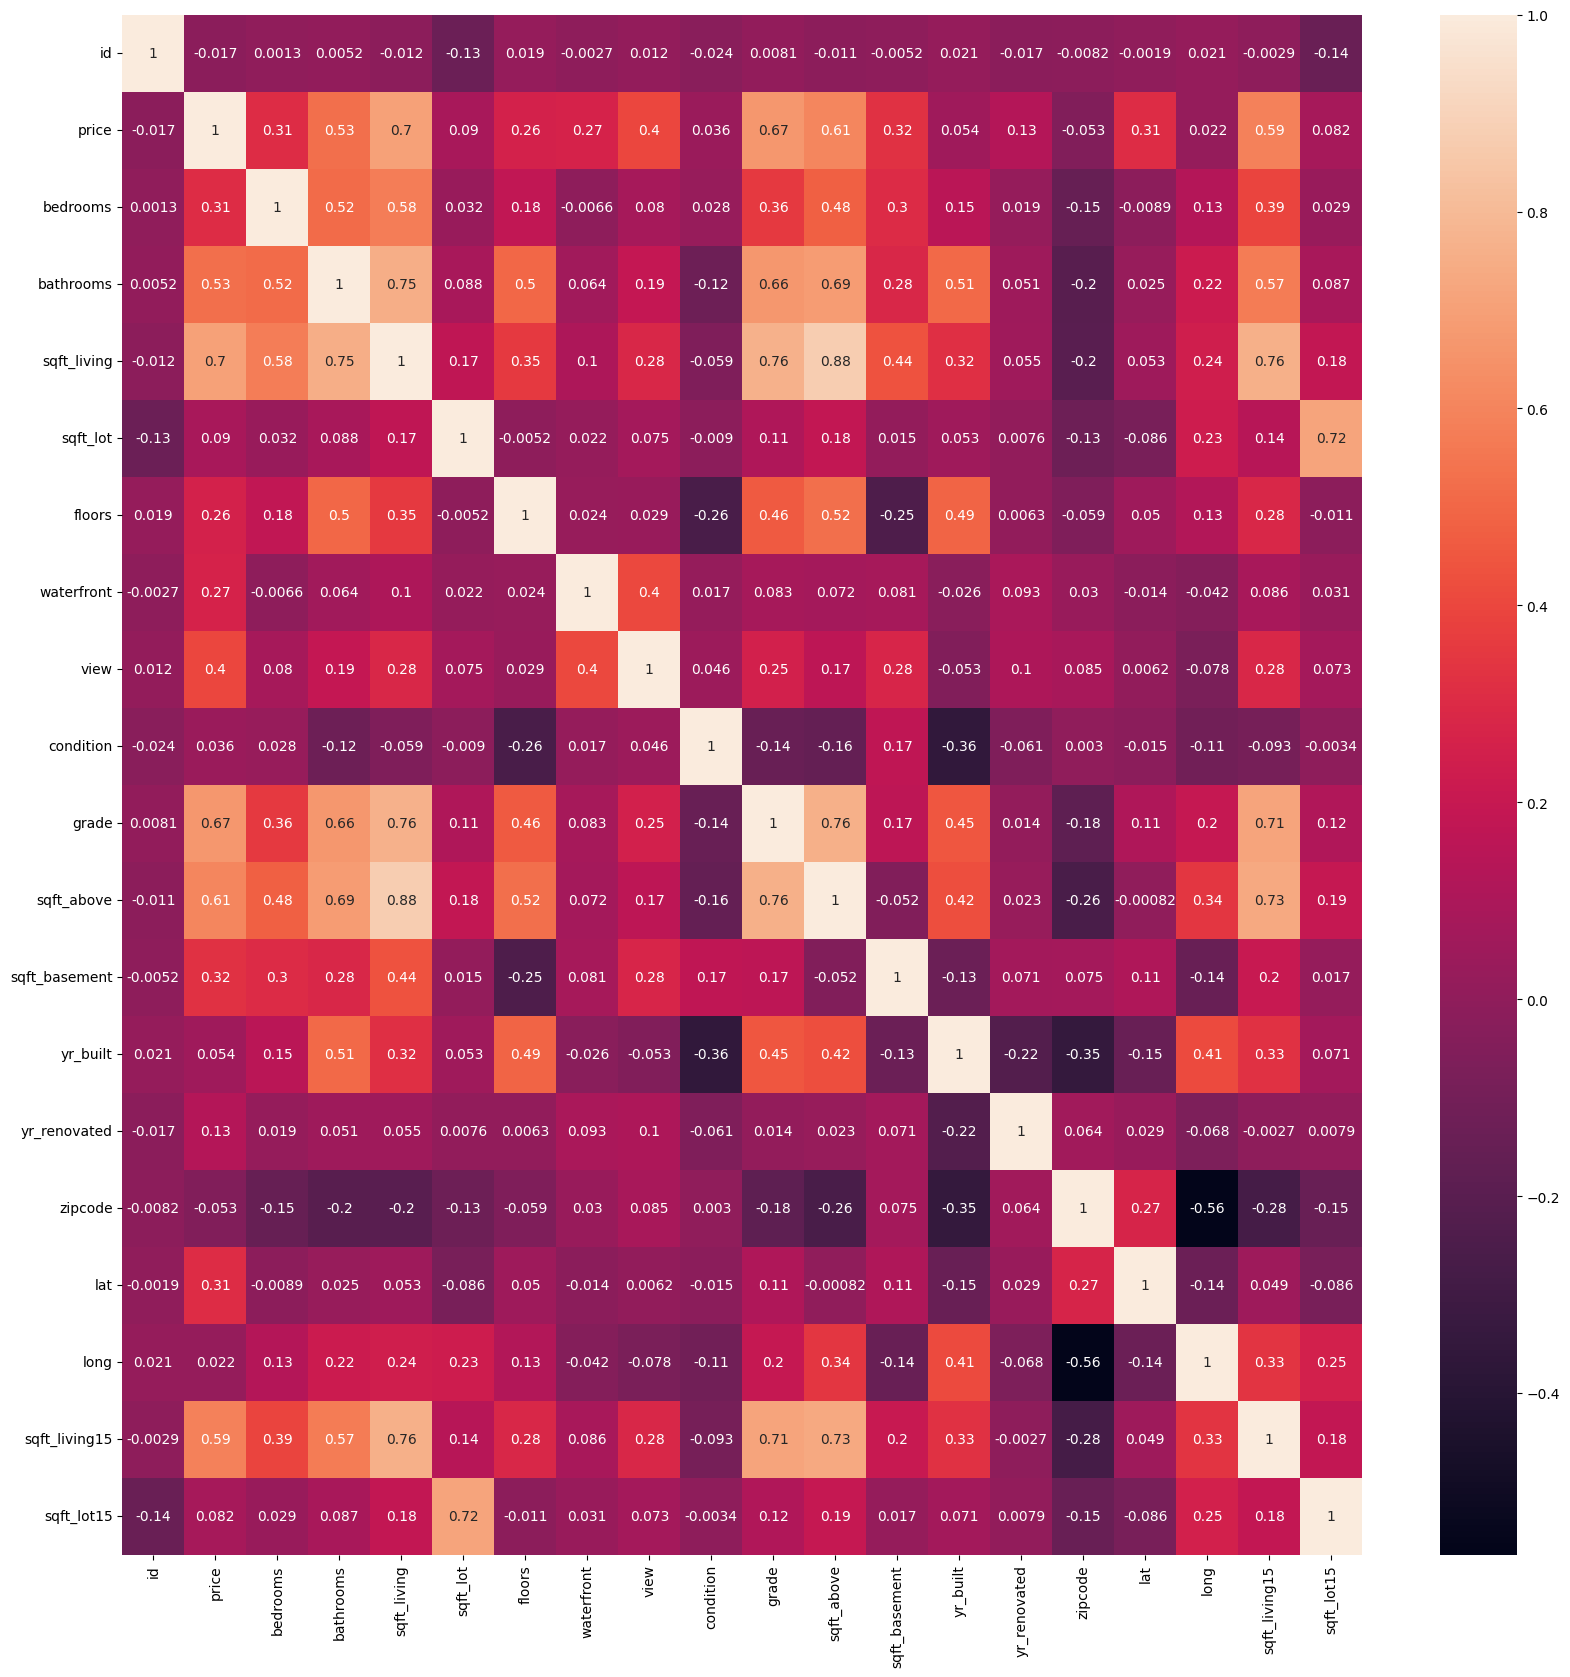

In [83]:
figura = plt.figure(figsize=(20,20))
sns.heatmap(base_casas.corr(), annot=True)

In [84]:
x_casas = base_casas.iloc[:, 5:6].values
x_casas

array([[ 5650],
       [ 7242],
       [10000],
       ...,
       [ 1350],
       [ 2388],
       [ 1076]], shape=(21613, 1))

In [85]:
y_casas = base_casas.iloc[:,1].values
y_casas

array([221900., 538000., 180000., ..., 402101., 400000., 325000.],
      shape=(21613,))

In [86]:
from sklearn.model_selection import train_test_split
x_casas_treinamento, x_casas_teste, y_casas_treinamento, y_casas_teste = train_test_split(x_casas, y_casas, test_size=0.3, random_state=0)

In [87]:
x_casas_treinamento.shape, y_casas_treinamento.shape

((15129, 1), (15129,))

In [88]:
x_casas_teste.shape, y_casas_teste.shape

((6484, 1), (6484,))

In [89]:
from sklearn.linear_model import LinearRegression
regressor_simples_casa = LinearRegression()
regressor_simples_casa.fit(x_casas_treinamento, y_casas_treinamento)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [90]:
#b0

regressor_simples_casa.intercept_

np.float64(528114.1878989475)

In [91]:
# b1

regressor_simples_casa.coef_

array([0.82092737])

In [92]:
regressor_simples_casa.score(x_casas_treinamento, y_casas_treinamento)

0.0089683233554686

In [93]:
previsoes = regressor_simples_casa.predict(x_casas_treinamento)
previsoes

array([534024.8649634 , 534120.09253832, 532529.95622251, ...,
       540387.05208138, 591050.58472477, 541442.76467928], shape=(15129,))

In [94]:
grafico = px.scatter(x = x_casas_treinamento.ravel(), y = previsoes)
grafico.show()

In [95]:
grafico1 = px.scatter(x = x_casas_treinamento.ravel(), y = y_casas_treinamento)
grafico2 = px.line(x = x_casas_treinamento.ravel(), y = previsoes)
grafico2.data[0].line.color = 'red'
grafico3 = go.Figure(data=grafico1.data + grafico2.data)
grafico3

In [96]:
previsoes_teste = regressor_simples_casa.predict(x_casas_teste)
previsoes_teste

array([529468.71805955, 570667.7790535 , 531151.61916818, ...,
       549216.1259464 , 534688.99520578, 535698.73587095], shape=(6484,))

In [97]:
y_casas_teste

array([ 297000., 1578000.,  562100., ...,  380000.,  268000.,  206000.],
      shape=(6484,))

In [98]:
abs(y_casas_teste - previsoes_teste).mean()

np.float64(233149.2751022328)

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [100]:
mean_absolute_error(y_casas_teste, previsoes_teste)

233149.2751022328

In [101]:
mean_squared_error(y_casas_teste, previsoes_teste)

136484753116.20659

In [102]:
np.sqrt(mean_squared_error(y_casas_teste, previsoes_teste))

np.float64(369438.429398197)

In [103]:
grafico1 = px.scatter(x = x_casas_teste.ravel(), y = y_casas_teste)
grafico2 = px.line(x = x_casas_teste.ravel(), y = previsoes_teste)
grafico2.data[0].line.color = 'red'
grafico3 = go.Figure(data=grafico1.data + grafico2.data)
grafico3

# Regressão Linear Múltipla

In [113]:
base_casas = pd.read_csv("D:/cursos/curso-machine-learning/bases_dados/house_prices.csv")

In [105]:
x_casas = base_casas.iloc[:, 3:19].values
x_casas

array([[ 3.00000e+00,  1.00000e+00,  1.18000e+03, ...,  9.81780e+04,
         4.75112e+01, -1.22257e+02],
       [ 3.00000e+00,  2.25000e+00,  2.57000e+03, ...,  9.81250e+04,
         4.77210e+01, -1.22319e+02],
       [ 2.00000e+00,  1.00000e+00,  7.70000e+02, ...,  9.80280e+04,
         4.77379e+01, -1.22233e+02],
       ...,
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ...,  9.81440e+04,
         4.75944e+01, -1.22299e+02],
       [ 3.00000e+00,  2.50000e+00,  1.60000e+03, ...,  9.80270e+04,
         4.75345e+01, -1.22069e+02],
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ...,  9.81440e+04,
         4.75941e+01, -1.22299e+02]], shape=(21613, 16))

In [106]:
y_casas = base_casas.iloc[:, 2].values
y_casas

array([221900., 538000., 180000., ..., 402101., 400000., 325000.],
      shape=(21613,))

In [107]:
x_casas_train, x_casas_test, y_casas_train, y_casas_test = train_test_split(x_casas, y_casas, test_size=0.3, random_state=0)

In [108]:
x_casas_train.shape, x_casas_test.shape

((15129, 16), (6484, 16))

In [109]:
y_casas_train.shape, y_casas_test.shape

((15129,), (6484,))

In [110]:
regressor_linear_multiplo = LinearRegression()
regressor_linear_multiplo.fit(x_casas_train, y_casas_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [111]:
regressor_linear_multiplo.intercept_

np.float64(5736222.703412161)

In [114]:
len(regressor_linear_multiplo.coef_)

16

In [115]:
regressor_linear_multiplo.score(x_casas_train, y_casas_train)

0.7029888085955007

In [116]:
regressor_linear_multiplo.score(x_casas_test, y_casas_test)

0.6885414149062644

In [117]:
previsoes = regressor_linear_multiplo.predict(x_casas_test)
previsoes

array([ 383751.77768702, 1514216.17517451,  546921.96179115, ...,
        314968.5762327 ,  219405.55573559,  148128.83467043],
      shape=(6484,))

In [118]:
y_casas_test

array([ 297000., 1578000.,  562100., ...,  380000.,  268000.,  206000.],
      shape=(6484,))

In [119]:
abs(y_casas_test - previsoes).mean()

np.float64(123888.44377485868)

In [120]:
mean_absolute_error(y_casas_test, previsoes)

123888.44377485868

In [122]:
mean_squared_error(y_casas_test, previsoes)

42760757001.53654

In [121]:
np.sqrt(mean_squared_error(y_casas_test, previsoes))

np.float64(206786.74280895412)